# Actividad 2. Calidad, drift y anomalías

Ignacio Agustin Costarelli - a2213

Analizo `ds_salaries.csv` siguiendo las consignas de la Actividad 2.
Comparo los períodos 2020–2021 y 2022–2023 mediante chequeos
de calidad y PSI. Después aplico Isolation Forest y LOF al dataset completo y
examino un registro marcado como anómalo.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import great_expectations as gx
from IPython.display import display
from matplotlib.ticker import FuncFormatter, PercentFormatter
from evidently import Report, Dataset, DataDefinition
from evidently.metrics import ValueDrift
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

## 1. Preparación de los datos

Elijo `salary_in_usd`, `experience_level`, `remote_ratio` y `company_size`.
El salario está expresado en USD. La experiencia distingue los niveles EN inicial,
MI intermedio, SE senior y EX ejecutivo. La modalidad remota toma los valores
0 para presencial, 50 para híbrida y 100 para remota. El tamaño de empresa usa
S para pequeña, M para mediana y L para grande.

Trato las últimas tres variables como categóricas. Divido los registros en referencia
para 2020–2021 y actual para 2022–2023. Conservo el índice del CSV como `registro`
para ubicar cada fila. Ese índice no identifica a una persona.

In [48]:
df = pd.read_csv('ds_salaries.csv')
df.index.name = 'registro'

VARIABLES = ['salary_in_usd', 'experience_level', 'remote_ratio', 'company_size']
CATEGORICAS = VARIABLES[1:]
DOMINIOS = {
    'experience_level': ['EN', 'MI', 'SE', 'EX'],
    'remote_ratio': [0, 50, 100],
    'company_size': ['S', 'M', 'L'],
}

referencia = df.loc[df['work_year'].isin([2020, 2021])].copy()
actual = df.loc[df['work_year'].isin([2022, 2023])].copy()
periodos = {'Referencia': referencia, 'Actual': actual}

display(df.head())
resumen_periodos = pd.DataFrame([
    {'Período': nombre, 'Registros': len(datos),
     'Mediana salarial USD': datos['salary_in_usd'].median()}
    for nombre, datos in periodos.items()
])
display(resumen_periodos)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
registro,,,,,,,,,,,
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


,Período,Registros,Mediana salarial USD
0,Referencia,306,79833.0
1,Actual,3449,138750.0


La referencia tiene 306 registros y el período actual 3.449. Comparo proporciones
para contemplar el distinto tamaño de las muestras. La mediana salarial pasa de
USD 79.833 a USD 138.750. Esto describe la muestra, pero no permite concluir que
el salario de las mismas personas haya aumentado ni que ambos períodos representen
de igual manera al mercado laboral.

## 2. Chequeos de calidad

Calidad y drift, punto a.

Aplico completitud, validez, unicidad y consistencia con Great Expectations.
Creo un batch por período y ejecuto cada expectativa
de forma explícita. Para los chequeos considero faltantes las cadenas vacías o
compuestas solo por espacios, trabajando sobre una copia de los datos.

In [49]:
context = gx.get_context(mode='ephemeral')
context.enable_analytics(False)
context.variables.progress_bars = {'globally': False}
data_source = context.data_sources.add_pandas('salarios')

batches = {}
for nombre, datos in periodos.items():
    data_asset = data_source.add_dataframe_asset(name=nombre)
    batch_definition = data_asset.add_batch_definition_whole_dataframe('batch_completo')
    datos_chequeo = datos.copy().replace(r'^\s*$', np.nan, regex=True)
    batches[nombre] = batch_definition.get_batch(
        batch_parameters={'dataframe': datos_chequeo}
    )

### 2.1. Completitud

Compruebo que las cuatro variables elegidas no tengan faltantes. Exijo el cumplimiento
en todas las filas con `mostly=1.0`, porque estos campos se necesitan para el análisis.

In [50]:
completitud = []
for nombre, batch in batches.items():
    for variable in VARIABLES:
        resultado = batch.validate(
            gx.expectations.ExpectColumnValuesToNotBeNull(column=variable, mostly=1.0)
        )
        completitud.append({
            'Período': nombre, 'Variable': variable,
            'Faltantes': resultado.result['unexpected_count'],
            'Estado': 'OK' if resultado.success else 'ALERTA',
        })
display(pd.DataFrame(completitud))

,Período,Variable,Faltantes,Estado
0,Referencia,salary_in_usd,0,OK
1,Referencia,experience_level,0,OK
2,Referencia,remote_ratio,0,OK
3,Referencia,company_size,0,OK
4,Actual,salary_in_usd,0,OK
5,Actual,experience_level,0,OK
6,Actual,remote_ratio,0,OK
7,Actual,company_size,0,OK


### 2.2. Validez

Verifico las columnas del archivo, los salarios mayores que cero y las categorías
permitidas. También compruebo que el salario sea numérico y finito. No fijo un máximo
salarial arbitrario, porque un monto alto no demuestra por sí solo un error.

In [51]:
columnas_esperadas = [
    'work_year', 'experience_level', 'employment_type', 'job_title', 'salary',
    'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio',
    'company_location', 'company_size',
]

validez = []
for nombre, batch in batches.items():
    resultado_esquema = batch.validate(
        gx.expectations.ExpectTableColumnsToMatchSet(column_set=columnas_esperadas)
    )
    validez.append({
        'Período': nombre, 'Control': 'Columnas esperadas',
        'Estado': 'OK' if resultado_esquema.success else 'ALERTA',
    })

    salario = periodos[nombre]['salary_in_usd']
    salario_valido = pd.api.types.is_numeric_dtype(salario) and np.isfinite(salario).all()
    validez.append({
        'Período': nombre, 'Control': 'Salario numérico y finito',
        'Estado': 'OK' if salario_valido else 'ALERTA',
    })

    resultado_rango = batch.validate(
        gx.expectations.ExpectColumnValuesToBeBetween(
            column='salary_in_usd', min_value=0, strict_min=True, mostly=1.0
        )
    )
    validez.append({
        'Período': nombre, 'Control': 'Salario mayor que cero',
        'Estado': 'OK' if resultado_rango.success else 'ALERTA',
    })

    for variable, valores in DOMINIOS.items():
        resultado_categorias = batch.validate(
            gx.expectations.ExpectColumnValuesToBeInSet(
                column=variable, value_set=valores, mostly=1.0
            )
        )
        validez.append({
            'Período': nombre, 'Control': f'Dominio de {variable}',
            'Estado': 'OK' if resultado_categorias.success else 'ALERTA',
        })
display(pd.DataFrame(validez))

,Período,Control,Estado
0,Referencia,Columnas esperadas,OK
1,Referencia,Salario numérico y finito,OK
2,Referencia,Salario mayor que cero,OK
3,Referencia,Dominio de experience_level,OK
4,Referencia,Dominio de remote_ratio,OK
5,Referencia,Dominio de company_size,OK
6,Actual,Columnas esperadas,OK
7,Actual,Salario numérico y finito,OK
8,Actual,Salario mayor que cero,OK
9,Actual,Dominio de experience_level,OK


### 2.3. Unicidad

Busco filas completas repetidas. Great Expectations cuenta todos los integrantes
de los grupos repetidos. Muestro también las repeticiones posteriores a la primera
mediante `duplicated()`. La coincidencia de valores es una alerta para revisar,
porque el archivo no tiene un identificador de persona u oferta.

In [52]:
unicidad = []
for nombre, batch in batches.items():
    resultado = batch.validate(
        gx.expectations.ExpectCompoundColumnsToBeUnique(
            column_list=columnas_esperadas, mostly=1.0, ignore_row_if='never'
        )
    )
    unicidad.append({
        'Período': nombre,
        'Filas en grupos repetidos': resultado.result['unexpected_count'],
        'Repeticiones adicionales': periodos[nombre].duplicated().sum(),
        'Estado': 'OK' if resultado.success else 'ALERTA',
    })
display(pd.DataFrame(unicidad))

,Período,Filas en grupos repetidos,Repeticiones adicionales,Estado
0,Referencia,6,3,ALERTA
1,Actual,1709,1168,ALERTA


### 2.4. Consistencia

En los registros cuya moneda es USD, `salary` debe coincidir con `salary_in_usd`.
Uso `salary` y `salary_currency` como columnas auxiliares para este chequeo.
La igualdad entre campos comprueba consistencia interna, pero no exactitud contra
una fuente externa.

In [53]:
consistencia = []
for nombre, datos in periodos.items():
    datos_usd = datos.loc[datos['salary_currency'].eq('USD')].copy()
    asset_usd = data_source.add_dataframe_asset(name=f'{nombre}_usd')
    definition_usd = asset_usd.add_batch_definition_whole_dataframe('batch_usd')
    batch_usd = definition_usd.get_batch(batch_parameters={'dataframe': datos_usd})
    resultado = batch_usd.validate(
        gx.expectations.ExpectColumnPairValuesToBeEqual(
            column_A='salary', column_B='salary_in_usd',
            mostly=1.0, ignore_row_if='neither'
        )
    )
    consistencia.append({
        'Período': nombre, 'Registros en USD': len(datos_usd),
        'Inconsistencias': resultado.result['unexpected_count'],
        'Estado': 'OK' if resultado.success else 'ALERTA',
    })
display(pd.DataFrame(consistencia))

,Período,Registros en USD,Inconsistencias,Estado
0,Referencia,160,0,OK
1,Actual,3064,0,OK


Los chequeos de completitud, validez y consistencia se cumplen en ambos períodos.
La unicidad genera alertas por 3 repeticiones adicionales en referencia y 1.168
en actual. Son 1.171 repeticiones sobre 3.755 registros, equivalentes al 31,2%.
Great Expectations cuenta 6 y 1.709 filas, respectivamente, porque incluye la
primera aparición de cada grupo repetido.

Conservo todas las filas, como en la Actividad 1, hasta confirmar su procedencia.
Las repeticiones pueden influir en las distribuciones y en la densidad local de LOF.
No puedo evaluar exactitud sin una fuente externa ni oportunidad temporal sin
fechas de llegada y plazos esperados de disponibilidad.

## 3. Calidad y drift mediante PSI

Calidad y drift, puntos b y c.

Comparo las distribuciones de las cuatro variables. Para el salario uso la
distribución acumulada y para las categóricas, proporciones dentro de cada período.

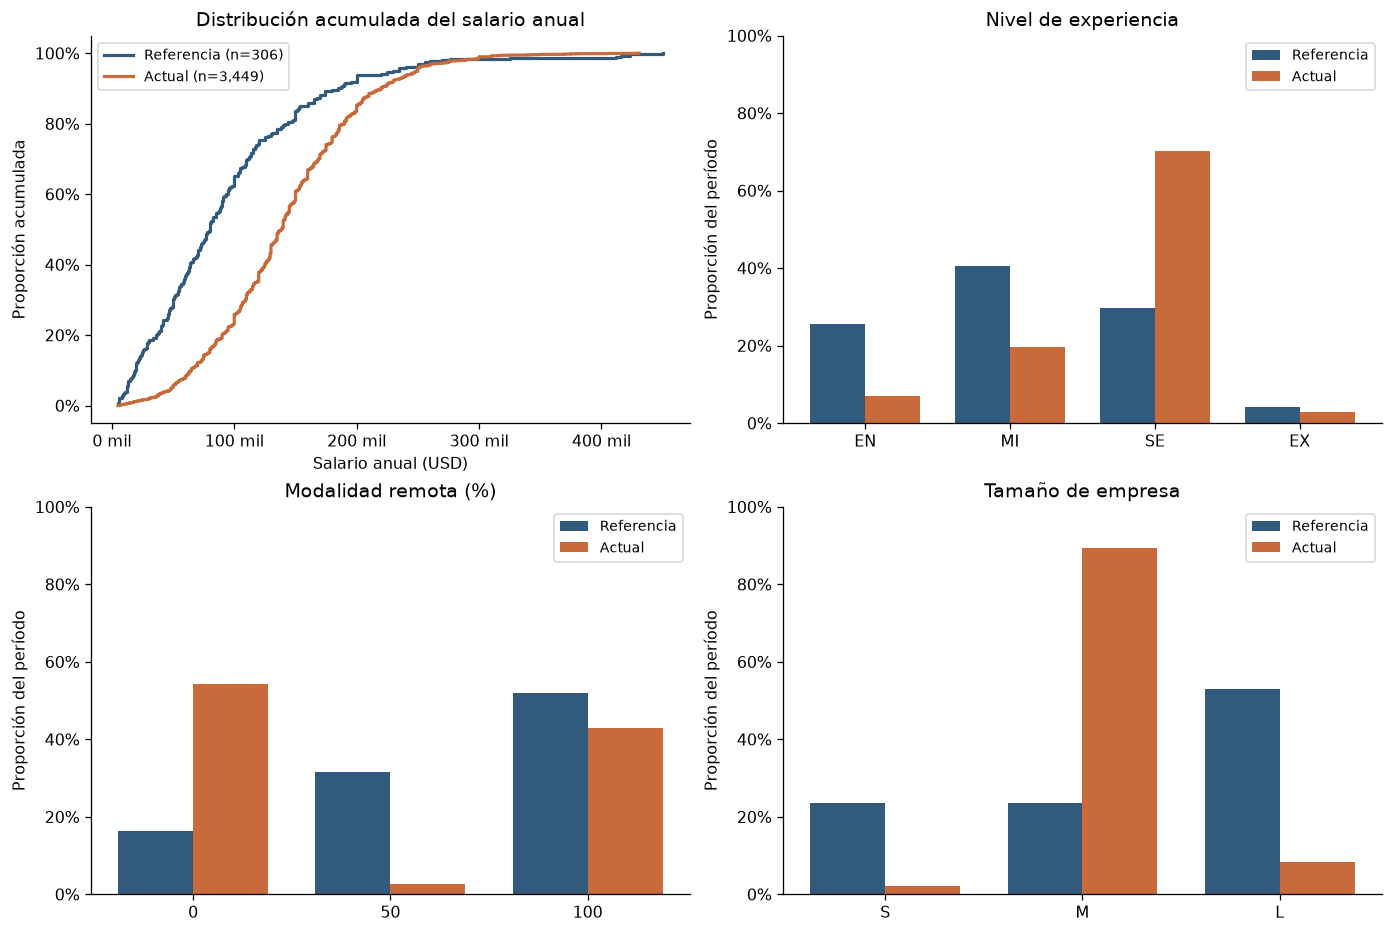

In [54]:
ETIQUETAS = {
    'salary_in_usd': 'Salario anual en USD',
    'experience_level': 'Nivel de experiencia',
    'remote_ratio': 'Modalidad remota (%)',
    'company_size': 'Tamaño de empresa',
}
COLORES = {'Referencia': '#315A7D', 'Actual': '#C86A39'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
ax = axes[0, 0]
for nombre, datos in periodos.items():
    valores = np.sort(datos['salary_in_usd'].to_numpy())
    ax.step(valores, np.arange(1, len(valores) + 1) / len(valores), where='post',
            label=f'{nombre} (n={len(datos):,})', color=COLORES[nombre], linewidth=2)
ax.set(title='Distribución acumulada del salario anual', xlabel='Salario anual (USD)', ylabel='Proporción acumulada')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x / 1000:.0f} mil'))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(fontsize=9)
for ax, variable in zip(axes.flat[1:], CATEGORICAS):
    posiciones = np.arange(len(DOMINIOS[variable]))
    for desplazamiento, (nombre, datos) in zip([-0.19, 0.19], periodos.items()):
        proporcion = datos[variable].value_counts(normalize=True).reindex(DOMINIOS[variable], fill_value=0)
        ax.bar(posiciones + desplazamiento, proporcion, width=0.38,
               color=COLORES[nombre], label=nombre)
    ax.set_xticks(posiciones, [str(v) for v in DOMINIOS[variable]])
    ax.set(title=ETIQUETAS[variable], ylabel='Proporción del período', ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(fontsize=9)
plt.show()

Calculo el PSI con `ValueDrift`, usando `method='psi'`.
Defino explícitamente las tres variables categóricas
para que `remote_ratio` no se interprete como una variable continua.

El PSI compara las proporciones de cada intervalo o categoría mediante

$$
PSI = \sum_i (p_{actual,i}-p_{ref,i})\ln\left(\frac{p_{actual,i}}{p_{ref,i}}\right).
$$

Uso la discretización y el tratamiento de proporciones nulas de Evidently.
En la implementación utilizada, el salario se divide en intervalos comunes con
la regla de Sturges sobre ambos períodos. Para las categóricas se comparan sus categorías.

Adopto un umbral de 0,25 para drift importante. Un PSI menor que 0,10
indica ausencia de una alerta relevante con este criterio y entre 0,10 y 0,25
indica un cambio moderado que requiere investigación. Estos umbrales son
orientativos y no representan una prueba de significación estadística.

In [55]:
UMBRAL_PSI = 0.25
definicion = DataDefinition(
    numerical_columns=['salary_in_usd'], categorical_columns=CATEGORICAS
)
ref_dataset = Dataset.from_pandas(referencia[VARIABLES], data_definition=definicion)
actual_dataset = Dataset.from_pandas(actual[VARIABLES], data_definition=definicion)

reporte = Report(metrics=[
    ValueDrift(column=variable, method='psi', threshold=UMBRAL_PSI)
    for variable in VARIABLES
])
resultado_psi = reporte.run(actual_dataset, ref_dataset)

filas_psi = []
for metrica in resultado_psi.dict()['metrics']:
    psi = metrica['value']
    if psi >= UMBRAL_PSI:
        conclusion = 'Drift importante'
    elif psi >= 0.10:
        conclusion = 'Cambio moderado'
    else:
        conclusion = 'Sin alerta relevante'
    filas_psi.append({
        'Variable': metrica['config']['column'], 'PSI': psi,
        'Umbral': UMBRAL_PSI, 'Conclusión': conclusion,
    })
resumen_psi = pd.DataFrame(filas_psi)
display(resumen_psi.round(3))

,Variable,PSI,Umbral,Conclusión
0,salary_in_usd,0.920,0.25,Drift importante
1,experience_level,0.742,0.25,Drift importante
2,remote_ratio,1.191,0.25,Drift importante
3,company_size,2.198,0.25,Drift importante


### Interpretación por variable

| Variable | PSI | Evidencia y conclusión |
|---|---|---|
| `salary_in_usd` | 0,920 | Supera 0,25. La mediana aumenta de USD 79.833 a USD 138.750. Cambia la distribución del objetivo P(y), compatible con target shift o label shift. |
| `experience_level` | 0,742 | Supera 0,25. La proporción senior pasa de 29,7% a 70,3%. El cambio en esta entrada es compatible con covariate shift. |
| `remote_ratio` | 1,191 | Supera 0,25. La modalidad híbrida baja de 31,7% a 2,7% y la presencial sube de 16,3% a 54,3%. Es compatible con covariate shift. |
| `company_size` | 2,198 | Supera 0,25 y presenta el mayor PSI. Las empresas medianas pasan de 23,5% a 89,3%. El cambio de composición es compatible con covariate shift. |

Los PSI muestran cambios marginales, pero no permiten afirmar que se cumplan todas
las condiciones de un tipo de shift puro. No comprueban que P(y\|X) permanezca estable
ni que haya cambiado. Por eso no puedo confirmar ni descartar concept drift con este
análisis. El salario podría variar porque cambió la composición de experiencia,
modalidad, tamaño de empresa, países o puestos.

Con solo dos períodos agregados tampoco puedo distinguir si el cambio fue abrupto,
gradual o recurrente. Para eso necesitaría ventanas temporales más detalladas y
evaluar el desempeño del modelo a lo largo del tiempo.

## 4. Estrategia para el modelo de la Actividad 1

Calidad y drift, punto d.

Elegiría reentrenar desde cero incorporando datos recientes.
Las cuatro variables muestran cambios de distribución, por lo que
conviene revisar si el modelo sigue funcionando en la población actual.
Mantendría fuera `salary`, como en el modelo final de la Actividad 1, para evitar
usar el mismo monto que se busca predecir.

Compararía un modelo entrenado con 2020–2021 y otro entrenado con 2020–2022,
evaluando ambos sobre 2023 mediante MAE y RMSE. Ajustaría el preprocesamiento
solo con los datos de entrenamiento. No reutilizaría directamente el modelo de
la Actividad 1 para esa comparación temporal porque su partición aleatoria podía
incluir registros de 2023 en entrenamiento.

Elegiría reentrenamiento antes que agregar variables sin evidencia de su utilidad
o mantener varios modelos mediante un ensamble. Incorporaría el candidato solo
si mejora en el período de evaluación y revisaría también los errores por experiencia
y país. El PSI justifica esta evaluación, pero no demuestra por sí mismo una caída
del desempeño. Esta sección propone la estrategia solicitada, sin ejecutar un
nuevo entrenamiento.

## 5. Detección de anomalías

Detección de anomalías, punto a.

### 5.1. Preparación de las variables

Uso las mismas cuatro variables sobre todas las filas. Transformo el salario con
`log1p` para comprimir su asimetría y lo estandarizo con `StandardScaler`.
Codifico las tres categóricas con one-hot, sin escalar sus columnas binarias.
Así evito asignar distancias ordinales arbitrarias a sus categorías.

El salario es una variable observada del detector. No se está entrenando un modelo
supervisado para predecirlo. No incorporo `salary`, que repetiría el monto, ni
`work_year`, para evitar que el período se convierta directamente en una señal de anomalía.

Uso 300 árboles y semilla 42 en Isolation Forest. En LOF elijo 40 vecinos porque
la máxima cantidad de copias de un mismo perfil es 38. Esto evita vecindarios
compuestos exclusivamente por copias a distancia cero, aunque las repeticiones
pueden seguir influyendo en la densidad. Fijo `contamination=0.05` en ambos métodos
como criterio exploratorio de selección, sin interpretar ese 5% como errores reales.

In [56]:
escalador = StandardScaler()
salario_transformado = escalador.fit_transform(np.log1p(df[['salary_in_usd']]))
codificador = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorias_transformadas = codificador.fit_transform(df[CATEGORICAS].astype(str))
X_escalado = np.column_stack([salario_transformado, categorias_transformadas])

max_repeticiones = df.groupby(VARIABLES, observed=True).size().max()
print(f'Máxima cantidad de copias de un perfil igual a {max_repeticiones}')
print(f'Analizo {len(df)} filas con {X_escalado.shape[1]} columnas transformadas')
resultados = df.copy()

Máxima cantidad de copias de un perfil igual a 38
Analizo 3755 filas con 11 columnas transformadas


### 5.2. Isolation Forest

Uso `fit_predict` para obtener las etiquetas y `decision_function` para los scores.
La etiqueta −1 indica anomalía y 1 indica normalidad. Un score negativo queda
del lado anómalo del umbral de decisión, situado en cero.

In [57]:
if_model = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
resultados['isof_pred'] = if_model.fit_predict(X_escalado)
resultados['isof_score'] = if_model.decision_function(X_escalado)

print(f'Isolation Forest detecta {(resultados["isof_pred"] == -1).sum()} anomalías')
display(resultados.sort_values('isof_score').head(5)[
    VARIABLES + ['isof_pred', 'isof_score']
])

Isolation Forest detecta 188 anomalías


,salary_in_usd,experience_level,remote_ratio,company_size,isof_pred,isof_score
registro,,,,,,
2022,10000,SE,50,S,-1,-0.062110
3593,6072,EN,0,S,-1,-0.058080
1548,6304,EN,0,S,-1,-0.058080
573,7000,EN,0,S,-1,-0.057121
1917,10000,EN,50,S,-1,-0.054954


### 5.3. Local Outlier Factor

Uso `fit_predict` para obtener las etiquetas y `negative_outlier_factor_` para los scores.
La etiqueta −1 indica anomalía. El score es el negativo del LOF, por lo que valores
más negativos indican mayor anomalía local. Un valor próximo a −1 corresponde
a una densidad similar a la de los vecinos.

In [58]:
lof = LocalOutlierFactor(n_neighbors=40, contamination=0.05)
resultados['lof_pred'] = lof.fit_predict(X_escalado)
resultados['lof_score'] = lof.negative_outlier_factor_

print(f'LOF detecta {(resultados["lof_pred"] == -1).sum()} anomalías')
print(f'Umbral del score LOF igual a {lof.offset_:.4f}')
display(resultados.sort_values('lof_score').head(5)[
    VARIABLES + ['lof_pred', 'lof_score']
])

LOF detecta 185 anomalías
Umbral del score LOF igual a -2.0567


,salary_in_usd,experience_level,remote_ratio,company_size,lof_pred,lof_score
registro,,,,,,
3745,168000,SE,0,S,-1,-73.593453
3642,190000,SE,100,S,-1,-47.229722
3609,260000,SE,0,S,-1,-44.506147
2651,161311,SE,50,M,-1,-33.255961
3613,109024,SE,50,M,-1,-32.781533


### 5.4. Registro elegido e interpretación

Detección de anomalías, puntos b, c y d.

Selecciono el mayor salario entre los registros marcados por al menos un método.
Reviso sus valores originales y comparo el salario con la regla IQR. Considero
univariadamente extremos los valores fuera de
`[Q1 − 1,5 × IQR, Q3 + 1,5 × IQR]`.

In [59]:
marcados = resultados.loc[
    (resultados['isof_pred'] == -1) | (resultados['lof_pred'] == -1)
]
registro_elegido = marcados['salary_in_usd'].idxmax()
caso = resultados.loc[registro_elegido]
display(resultados.loc[[registro_elegido]].T)

q1, q3 = df['salary_in_usd'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
display(pd.Series({
    'Q1 en USD': q1, 'Q3 en USD': q3, 'IQR en USD': iqr,
    'Límite inferior en USD': limite_inferior,
    'Límite superior en USD': limite_superior,
}, name='Regla univariada').to_frame())

print(f'Registro {registro_elegido} en la línea {registro_elegido + 2} del CSV')
print(f'Score IF de {caso["isof_score"]:.4f} frente al umbral de cero')
print(f'Score LOF de {caso["lof_score"]:.4f} frente al umbral de {lof.offset_:.4f}')

mismo_perfil = df[CATEGORICAS].eq(caso[CATEGORICAS]).all(axis=1)
display(df.loc[mismo_perfil, 'salary_in_usd'].describe().to_frame())

registro,3522
work_year,2020
experience_level,MI
employment_type,FT
job_title,Research Scientist
salary,450000
salary_currency,USD
salary_in_usd,450000
employee_residence,US
remote_ratio,0
company_location,US


,Regla univariada
Q1 en USD,95000.0
Q3 en USD,175000.0
IQR en USD,80000.0
Límite inferior en USD,-25000.0
Límite superior en USD,295000.0


Registro 3522 en la línea 3524 del CSV
Score IF de 0.0944 frente al umbral de cero
Score LOF de -3.5546 frente al umbral de -2.0567


,salary_in_usd
count,367.000000
mean,120496.950954
std,52600.210909
min,10000.000000
25%,86596.500000
50%,112000.000000
75%,150000.000000
max,450000.000000


El registro 3522 corresponde a un Research Scientist de 2020, nivel MI, empleo FT,
residencia y empresa en Estados Unidos, modalidad presencial y empresa mediana.
Su salario anual es USD 450.000. El campo `salary` también vale 450.000 y la moneda
es USD, por lo que los dos montos son consistentes.

Es un outlier univariado en salario porque supera el límite superior de USD 295.000,
calculado con Q1 de USD 95.000, Q3 de USD 175.000 e IQR de USD 80.000.
Dentro del perfil MI, presencial y empresa mediana hay 367 registros, con una
mediana salarial de USD 112.000. El salario del caso también resulta alto en ese grupo.

Los métodos no coinciden. LOF lo marca con un score de aproximadamente −3,555,
por debajo de su umbral de −2,057. Isolation Forest no lo marca, ya que su
`decision_function` es positiva, con un valor aproximado de 0,094.

LOF compara la densidad del punto con la de sus vecinos, mientras que Isolation
Forest evalúa cuán fácil es aislarlo mediante cortes aleatorios. La diferencia es
compatible con un salario poco denso frente a sus vecinos y un perfil con categorías
frecuentes que no se aísla tanto como otros perfiles del bosque. Además, el logaritmo
comprime los salarios altos y cada método selecciona aproximadamente su 5% más extremo.
Esta interpretación explica la diferencia de criterios, sin atribuir un aporte
exacto a cada variable.

El registro es univariadamente extremo y también recibe una alerta de un detector
multivariado. Ambas condiciones pueden coexistir.
No lo eliminaría automáticamente, primero revisaría su fuente y la definición de
remuneración anual, porque un salario extremo puede ser válido.

## 6. Conclusiones

Los chequeos de completitud, validez y consistencia se cumplen. La unicidad genera
alertas por las 1.171 repeticiones adicionales de filas completas, que conservo
hasta poder confirmar su procedencia.

Las cuatro variables superan el umbral PSI de 0,25. Los cambios son compatibles
con drift de las entradas y del objetivo, pero no permiten afirmar concept drift.
Propongo reentrenar con datos recientes y comprobar la mejora mediante una evaluación
temporal, manteniendo fuera `salary`.

Isolation Forest marca 188 registros y LOF 185. El registro 3522, con USD 450.000,
es un outlier univariado en salario que solo LOF marca en el ajuste utilizado.
La diferencia responde a los criterios de aislamiento y densidad local de los métodos.